In [ ]:
!pip install pymnet --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.9/138.9 kB 7.2 MB/s eta 0:00:00


In [ ]:
from pymnet import *
from pymnet import transforms
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

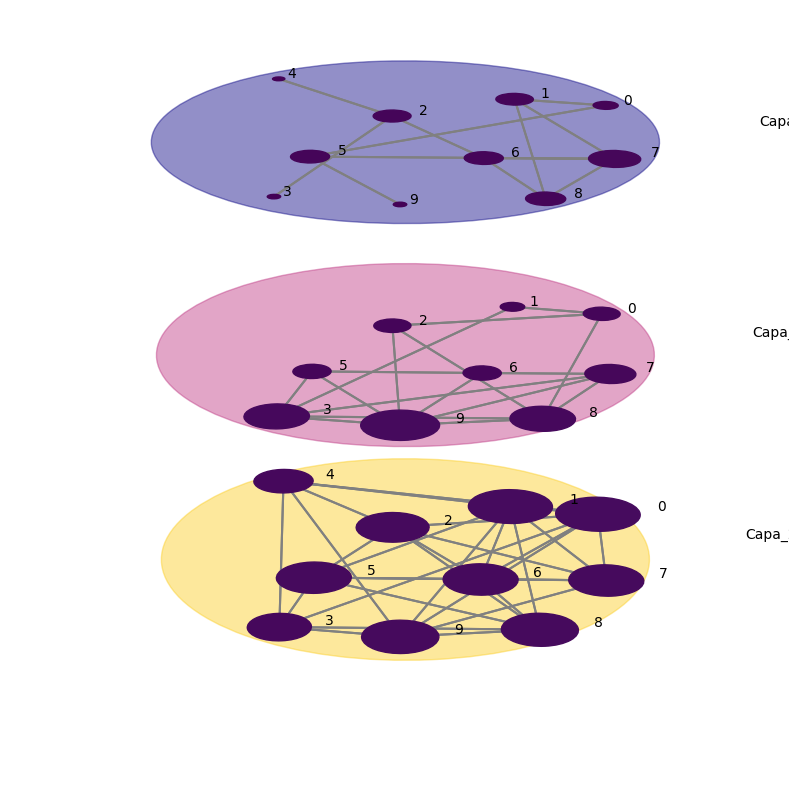

In [ ]:
n_nodos = 10
probabilidades = [0.25, 0.35, 0.60]

net = MultiplexNetwork()
#Capas
for i, p_capa in enumerate(probabilidades):
    capa_nombre = f"Capa_{i}"
    temp_er = models.er(n_nodos, p=p_capa)
    for edge in temp_er.edges:
        u, v = edge[0], edge[1]
        net[u, v, capa_nombre] = 1

#Visualización
layers = list(net.get_layers())
colors = [cm.plasma(i) for i in np.linspace(0, 0.9, len(layers))]
layer_color_dict = dict(zip(layers, colors))

fig = draw(net,
           layout='spring',
           layershape='circle',
           figsize=(15, 10),
           layergap=1.2,
           layerColorDict=layer_color_dict,
           nodeColorRule={'rule': 'degree', 'colormap': 'viridis'},
           nodeSizeRule={'rule': 'degree', 'propscale': 0.08},
           edgeStyleRule={'rule': 'edgetype', 'intra': '-', 'inter': ':'},
           defaultLayerAlpha=0.45
)

plt.show()

# Reducir la cantidad de aspectos de una capa (`aggregate`)



In [ ]:
#Si hay un único aspecto
n=net.MultiplexNetwork([('categorical',1.0)]) #Multicapa con 1 aspecto
an=transforms.aggregate(n,1)
print(f"Aspectos después de aggregate: {an.aspects}")

Aspectos después de aggregate: 0


In [ ]:
#Si hay dos o mas aspectos
n=MultiplexNetwork([('categorical',1.0), ('categorical',1.0)]) #2 aspectos
an1=transforms.aggregate(n,1)
an2=transforms.aggregate(n,2)
an12=transforms.aggregate(n,(1,2))
print(f"Aspectos después de aggregate: {an1.aspects}")
print(f"Aspectos después de aggregate: {an2.aspects}")
print(f"Aspectos luego de aggregate: {an12.aspects}")

Aspectos después de aggregate: 1
Aspectos después de aggregate: 1
Aspectos luego de aggregate: 0


In [ ]:
print(an1.get_layers(0))
print(an1.get_layers(1))
#Colapsamos el aspecto 2
print(an1.get_layers(2))

set()
set()


IndexError: list index out of range

¿Porque vuelve a dar error en layer 2 si colapsé una capa diferente a `an1`?

Porque en ambas, pasamos de 2 aspectos a 1. Aunque eliminemos el aspecto 1, el aspecto 2 pasa a ser el 1.

Si proyectamos un cubo (3D) sobre un plano, obtenemos un cuadrado (2D). No importa si lo aplastamos desde arriba o desde un lado, el resultado final siempre vive en 2 dimensiones.


In [ ]:
print(an2.get_layers(0))
print(an2.get_layers(1))
print(an2.get_layers(2))

set()
set()


IndexError: list index out of range

Finalmente, ¿cómo colapsa las aristas?

In [ ]:
#Multicapa (1 aspecto)
net = MultiplexNetwork([('categorical', 1.0)])
#Enlaces
net[1, 2, 'Capa_A'] = 1
net[1, 2, 'Capa_B'] = 1
net[3, 4, 'Capa_A'] = 1

print("--- RED MULTICAPA ---")

for edge in net.edges:
    u = edge[0]
    v = edge[1]
    capa = edge[2]
    peso = net[u, v, capa]
    if peso != 0:
      print(f"Enlace ({u}-{v}) en la '{capa}' -> Peso: {peso}")

#Colapsar la red
net_colapsada = transforms.aggregate(net, 1)

print("\n--- RED COLAPSADA / AGREGADA ---")
for edge in net_colapsada.edges:
    u = edge[0]
    v = edge[1]
    peso_final = net_colapsada[u, v]
    print(f"Enlace ({u}-{v}) -> Peso final sumado: {peso_final}")

--- RED MULTICAPA ---
Enlace (1-2) en la 'Capa_B' -> Peso: 1
Enlace (1-2) en la 'Capa_A' -> Peso: 1
Enlace (3-4) en la 'Capa_A' -> Peso: 1

--- RED COLAPSADA / AGREGADA ---
Enlace (1-2) -> Peso final sumado: 2
Enlace (3-4) -> Peso final sumado: 1


# Generalización de matriz de adyacencia (`supra_adjacency_matrix`)

Si tienes $N$ nodos y $L$ capas, la matriz de supradyacencia será de $(N \times L) \times (N \times L)$.

En las diagonales estarán bloques de matrices de cada capa, el resto de bloques representan los enlaces intercapa entre la capa $i$ y la capa $j$.

In [ ]:
from pymnet import *
from pymnet import transforms
import numpy as np

net = MultilayerNetwork(aspects=1)
net[1, 2, 'Capa_A'] = 1
net[1, 2, 'Capa_B'] = 1
net[3, 4, 'Capa_A'] = 1
#Intercapa
net[1, 1, 'Capa_A', 'Capa_B'] = 1
#Red Multicapa
#Si includeCouplings=True, devolverá la matriz con intercapa
 #si es False, devolverá la matriz con puros enlaces intra-capa
matrix_supra, nodes_layers = supra_adjacency_matrix(net, includeCouplings=True)
print("--- SUPRA-ADJACENCY MATRIX (8x8) ---")
print(matrix_supra.astype(int))

#Matriz de la Red Colapsada
net_colapsada = transforms.aggregate(net, 1)
#Como no hay aspectos, devolverá la matriz simple de 4x4.
matrix_simple, nodes_simple = supra_adjacency_matrix(net_colapsada)
print("\n--- MATRIZ DE ADYACENCIA COLAPSADA (4x4) ---")
print("Orden de los nodos:", nodes_simple)
print(matrix_simple.astype(int))

--- SUPRA-ADJACENCY MATRIX (8x8) ---
[[0 1 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]

--- MATRIZ DE ADYACENCIA COLAPSADA (4x4) ---
Orden de los nodos: [1, 2, 3, 4]
[[0 2 0 0]
 [2 0 0 0]
 [0 0 0 1]
 [0 0 1 0]]


# Grados de una red

In [ ]:
#Llave = grados, Valor = Cantidad de nodos con ese grado
dist_multicapa_dist = degs(net, degstype='distribution')
#Llave = nodo, Valor = Grado
dist_multicapa_node = degs(net, degstype='nodes')

print("--- DISTRIBUCIÓN DE GRADOS ---")
print(f"Multicapa con distribución: {dist_multicapa_dist}")
print(f"Multicapa con nodos: {dist_multicapa_node}")

--- DISTRIBUCIÓN DE GRADOS ---
Multicapa con distribución: {2: 2, 1: 4, 0: 2}
Multicapa con nodos: {(1, 'Capa_B'): 2, (1, 'Capa_A'): 2, (2, 'Capa_B'): 1, (2, 'Capa_A'): 1, (3, 'Capa_B'): 0, (3, 'Capa_A'): 1, (4, 'Capa_B'): 0, (4, 'Capa_A'): 1}


In [ ]:
#categorical: las capas son etiquetas (A, B)
#1.0: El peso de conexión de cada nodo consigo mismo en la otra capa
net = MultiplexNetwork([('categorical', 1.0)])

#Enlaces intra-capa
net[1, 2, 'Capa_A'] = 1
net[3, 4, 'Capa_A'] = 1

net[1, 2, 'Capa_B'] = 1

#Llave = Capa, Valor = {Grado: Cantidad de nodos con ese grado}
dist_por_capa = multiplex_degs(net, degstype='distribution')

#Llave = Capa, Valor = {Nodo: Grado}
nodos_por_capa = multiplex_degs(net, degstype='nodes')

print("--- ANÁLISIS MULTIPLEX ---")
print(f"Distribución: {dist_por_capa}")
print(f"\nGrados por nodo: {nodos_por_capa}")

--- ANÁLISIS MULTIPLEX ---
Distribución: {'Capa_B': {1: 2, 0: 2}, 'Capa_A': {1: 4}}

Grados por nodo: {'Capa_B': {1: 1, 2: 1, 3: 0, 4: 0}, 'Capa_A': {1: 1, 2: 1, 3: 1, 4: 1}}


# Densidad de una red

$$Densidad = \frac{E}{\frac{(N \cdot L)(N \cdot L - 1)}{2}}$$

E: Enlaces

N: Nodos

L: Capas

$$Densidad = \frac{(3+4)}{\frac{(4 \cdot 2)(4 \cdot 2 - 1)}{2}} = \frac{14}{56} = \frac{1}{4}$$

In [ ]:
#Red Multiplex (2 capas, 4 nodos)
#Automaticamente crea enlaces inter-capa (4)
net = MultiplexNetwork([('categorical', 1.0)])
net[1, 2, 'Capa_A'] = 1
net[3, 4, 'Capa_A'] = 1
net[1, 2, 'Capa_B'] = 1

#Densidad de la Red Multicapa
#Considera enlaces intra-capa y enlaces inter-capa
densidad_multi = density(net)

print("--- DENSIDAD ---")
print(f"Densidad Multicapa: {densidad_multi:.4f}")

--- DENSIDAD ---
Densidad Multicapa: 0.2500


$$Densidad_{i} = \frac{E_{i}}{\frac{(N_i)(N_i - 1)}{2}}$$

In [ ]:
#Densidad por capas: {Nombre_Capa: Valor_Densidad}
densidades_por_capa = multiplex_density(net)

print("--- DENSIDAD POR CAPA (Solo Intra-capa) ---")
for capa, dens in densidades_por_capa.items():
  print(f"Densidad en la '{capa}': {dens:.4f}")

--- DENSIDAD POR CAPA (Solo Intra-capa) ---
Densidad en la 'Capa_B': 0.1667
Densidad en la 'Capa_A': 0.3333


# Coeficiente de Clustering

## $c_{Be,i} = \frac{\sum_j^n \sum_h^n \sum_k^b ( A_{ijk} \sum_l^b (A_{ihl} \sum_m^b A_{jhm} ) )} {\sum_j^n \sum_h^n \sum_k^b (A_{ijk} \sum_l^b \max(A_{ihl},A_{jhl}) )}$

Barrett’s local clustering coefficient of a node in multiplex network.

In [ ]:
net = MultiplexNetwork([('categorical', 1.0)])

#CAPA A
net[1, 2, 'Capa_A'] = 1
net[2, 3, 'Capa_A'] = 1
net[1, 3, 'Capa_A'] = 1

#CAPA B
net[1, 2, 'Capa_B'] = 1

#Coeficiente de Barrett para el Nodo 1
net_agregada = transforms.aggregate(net, 1)

cc_nodo_1 = cc_barrett(net, 1, net_agregada)

print(f"--- CLUSTERING DE BARRETT ---")
print(f"Coeficiente del Nodo 1: {cc_nodo_1:.4f}")
print(f"Coeficiente del Nodo 2: {cc_barrett(net, 2, net_agregada):.4f}")
print(f"Coeficiente del Nodo 3: {cc_barrett(net, 3, net_agregada):.4f}")

--- CLUSTERING DE BARRETT ---
Coeficiente del Nodo 1: 0.2857
Coeficiente del Nodo 2: 0.2857
Coeficiente del Nodo 3: 0.5000


La siguiente función se usa para saber el número de triángulos y tripletes que hay para un nodo en especifico en cada capa. Un bug curioso que me encontré:


la función `cc_sequence` calcula y devuelve los resultados ordenando las capas *alfabéticamente* por defecto. Sin embargo, la función `net.get_layers()` devuelve las capas basándose en el "hash" de memoria de Python

In [ ]:
net = MultiplexNetwork([('categorical', 1.0)])
net[1, 2, 'Capa_A'] = 1
net[2, 3, 'Capa_A'] = 1
net[1, 3, 'Capa_A'] = 1
net[1, 2, 'Capa_B'] = 1

#Solucion al bug: Ordenar las capas alfabéticamente
capas_ordenadas = sorted(list(net.get_layers()))

#sequence: [Capa, Triángulos, Tuplas (V)]
tri_lista, tup_lista = cc_sequence(net, 1)

print("--- ANÁLISIS DE SECUENCIA DE CLUSTERING (Nodo 1) ---")
for i in range(len(capas_ordenadas)):
    capa = capas_ordenadas[i]
    tri = tri_lista[i]
    tup = tup_lista[i]

    print(f"Resultados para {capa}:")
    print(f"  > Triángulos: {tri}")
    print(f"  > Tuplas (V):  {tup}")
    print("-" * 25)

--- ANÁLISIS DE SECUENCIA DE CLUSTERING (Nodo 1) ---
Resultados para Capa_A:
  > Triángulos: 1
  > Tuplas (V):  1.0
-------------------------
Resultados para Capa_B:
  > Triángulos: 0
  > Tuplas (V):  0.0
-------------------------
